# The Big Titanic Challenge - Who survived, who died?

It's time to get our hands dirty and do some Machine Learning! This time you will do hyper parameter selection for a Neural Network.

## Relation to Assessments:

Solving this task can be used as basis for showing specific knowledge in Machine LEarning for an assessment in module *SE_14 Artificial Intelligence Basics*. This also requires you to document your experiments and have good reasons for the design decisions you make here. A more detailed task description is in the cell a bit further down.

## Shoutouts:

This homework is based on the Titanic challenge on Kaggle: https://www.kaggle.com/c/titanic

## General Description (taken from Kaggle)

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).



## Prerequisites

To run this notebook you should have the following libraries installed:
- numpy: an optimized library for dealing with tensor data
- pandas: a library for loading and modifying tabular datasets
- scikit-learn: the machine learning library we will use.
- tensorflow: a library for neural network models.

This notebook is designed to be opened in Google Colab. If you execute it on your own computer you may have to install additinal dependencies - e.g., the tool wget which is used for downloading the dataset.

## Imports

In [1]:
# Data Processing
import numpy as np
import pandas as pd

# ML Algorithms
import tensorflow as tf

# Plotting and Metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split


## The dataset

For this exercise we will load data that has been preprocessed already. During the preprocessing we have taken care of missing values and removed / refactored some of the columns to make the data easier to use for this exercise.

Here are the features of this dataset:
* Survived: 0=died, 1=survived
* Sex: 0=male, 1=female
* Embarked: Port of embarkment, 0=Southhampton, 1=Cherbourg, 2=Queenstown
* Title: 0=Mr, 1=Mrs, 2=Miss, 3=Master, 4=Royalty, 5=Officer
* AgeBin: 0=Baby, 1=Child, 2=Teenager, 3=Young Adult, 4=Adult, 5=Senior
* Family_Alone {Family_Small} [Family_Large]: 1=Passenger travelled alone {with 1 to 3 family members aboard} [with more than 4 family members aboard], 0=otherwise
* Pclass_ordinal: Ticket class, 1=1st class, 2=2nd class, 3=3rd class
* The rest is [dummy codings](https://en.wikiversity.org/wiki/Dummy_variable_(statistics)) of Pclass_ordinal, AgeBin, and Title. Wonder why one dummy is always missing? Read [here](https://www.algosome.com/articles/dummy-variable-trap-regression.html) about the dummy variable trap.

In [5]:
# Get data from Google Drive
!mkdir -p input
!wget -q --no-check-certificate 'https://drive.google.com/uc?export=download&id=1JSSkzCveHYangek7W26tZYcg--prxTVG' -O 'input/data.csv'

# Read train and test data into Pandas DataFrames
data = pd.read_csv('/content/input/data.csv')
data.sample(5)

data.drop(['FareClass'], axis=1, inplace=True)

# print five random data points as example
data.sample(5)

,Unnamed: 0,Survived,Sex,Embarked,Title,AgeBin,Family_Alone,Family_Small,Family_Large,Pclass_ordinal,...,Title_1,Title_2,Title_3,Title_4,Title_5,Age_1,Age_2,Age_3,Age_4,Age_5
330,330,1,1,2,2,3,0,1,0,3,...,0,1,0,0,0,0,0,1,0,0
59,59,0,0,0,3,1,0,0,1,3,...,0,0,1,0,0,1,0,0,0,0
466,466,0,0,0,0,3,1,0,0,2,...,0,0,0,0,0,0,0,1,0,0
361,361,0,0,1,0,3,0,1,0,2,...,0,0,0,0,0,0,0,1,0,0
606,606,0,0,0,0,3,1,0,0,3,...,0,0,0,0,0,0,0,1,0,0


The loaded data is part of the training data from the Kaggle challenge.

We'll do some more preprocessing steps here:
- Select specific columns (we'll use different columns than in our previous experiment to give the model more data to work with.
- Split into input (X) and output(y) data.
- Split into trainin data (X_train, y_train) and test data (X_test, y_test).

In [6]:
# Pick the features we would like to use for our model
feature_cols = ["Sex", "Embarked", "Title_1", "Title_2", "Title_3", "Title_4", "Title_5", "Age_1", "Age_2", "Age_3", "Age_4", "Age_5", "Family_Alone", "Family_Small", "Family_Large", "Pclass_2", "Pclass_3"]

# split into input (X) and output (y)
X, y = data[feature_cols], data["Survived"]

# Automatically split the data into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(X_test.shape)

(179, 17)


## Your Playground

### Task: Training a Neural Network

Last week you've trained some basic Machine Learning models. This time your task is to do hyper-parameter search for a Neural Network. Documenting this experiment is part of the task!

The below cell contains functioning code for a very basic functioning Neural Network with only one hidden layer with 2 neurons. Your task is to select hyper parameters for this Neural Network.

Please at east experiment with these hyper-parameters:
- Number of hidden layers: Maybe adding more hidden layers improves the model?
- Number of neurons per layer: The number of neurons in the first and last layer are defined by the data we work with. But the number of neurons in the hidden layers is not. This is something you can experiment with.
- Transfer function: The network below uses relu as transfer function. Maybe another function works better?
- optimizer: The network below uses sgd as optimizer. Maybe another one could work better for this problem?
- epochs: The network below trains for 50 epochs. Do you think this is the right number? Is it maybe too short? Or too long?
You may have to do some research to understand some of these parameters. This is intended. If you want to try other things, test different types of network, or change the experiment in another way, you are free to do this.


**Please document your experiments and conclusions in the cell below**. This is part of the task. If you want to submit this for an SE_14 assessment, you need to document your experiment procedure and results.

To help you evaluate the model, there are additional cells that ...
- Plot the development of training and test loss over the epochs.
- Plot the confusion matrix and print several metrics that may be useful to you.



## Experiment Results

Please document your training results in this cell. You should document:
- What you tried and what your results and conclusion were.
- Which model performed best.
- What your evaluation of the best model is. Is the result good or bad? Why? In addition to the actual score, please also discuss overfitting.
- Any other observations you made during the experiment.

In [17]:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(2, input_dim=17, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="sgd",
              loss='binary_crossentropy',
              metrics=["mse","mae", "binary_crossentropy", "accuracy"])


# train the model
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3898 - binary_crossentropy: 0.7406 - loss: 0.7406 - mae: 0.5165 - mse: 0.2732 - val_accuracy: 0.4358 - val_binary_crossentropy: 0.7373 - val_loss: 0.7373 - val_mae: 0.5167 - val_mse: 0.2717
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4968 - binary_crossentropy: 0.7201 - loss: 0.7201 - mae: 0.5089 - mse: 0.2632 - val_accuracy: 0.4525 - val_binary_crossentropy: 0.7261 - val_loss: 0.7261 - val_mae: 0.5121 - val_mse: 0.2662
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4916 - binary_crossentropy: 0.7077 - loss: 0.7077 - mae: 0.5033 - mse: 0.2571 - val_accuracy: 0.4860 - val_binary_crossentropy: 0.7173 - val_loss: 0.7173 - val_mae: 0.5079 - val_mse: 0.2619
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5121 - binary_crossentropy: 0.6972 - loss: 0.6972 - mae: 0.4985 - mse: 0.2519 - val_accuracy: 0.4749 - val_binary_crossentropy: 0.7101 - val_loss: 0.7101 - val_mae: 0.5042 -

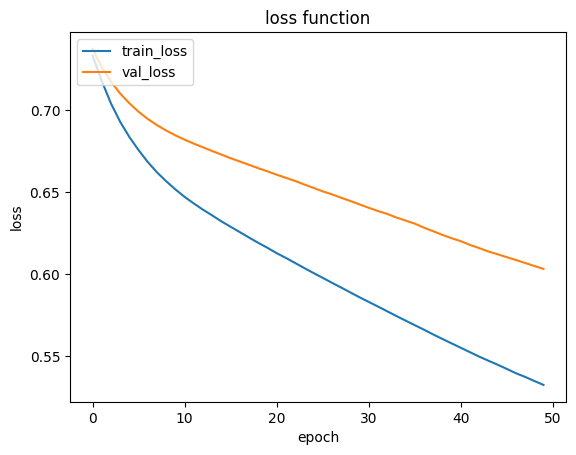

In [18]:
# compare training and validation loss function
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss function')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'], loc='upper left')
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-19-c4baf513bb6d>:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
<ipython-input-19-c4baf513bb6d>:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


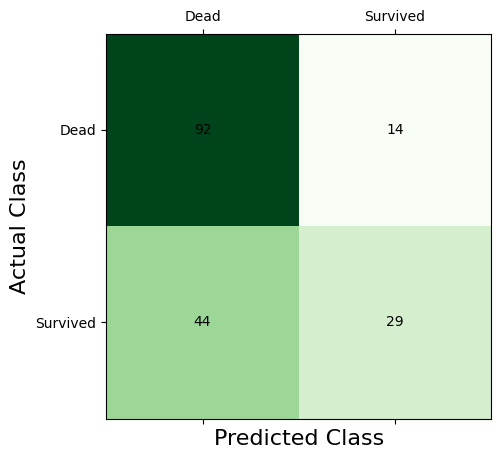

accuracy: 0.6759776536312849
precision: 0.6744186046511628
recall: 0.3972602739726027
F1 Score:  0.5


In [19]:

# calculate confusion matrix
Y_pred = model.predict(X_test)
Y_pred_classes = np.rint(Y_pred)
cm = confusion_matrix(y_test, Y_pred_classes)

#create and plot confusion matrix figure content
fig, ax = plt.subplots(figsize=(5, 5))
labels = ['','Dead','Survived']
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.matshow(cm, cmap=plt.cm.Greens)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center')

plt.xlabel('Predicted Class', fontsize=16)
plt.ylabel('Actual Class', fontsize=16)
plt.show()

#print precision & recall
accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0]+cm[1][0]+cm[0][1]+cm[1][1])
precision = cm[1][1] / (cm[0][1] + cm[1][1]) # true prositives / predicted positives
recall = cm[1][1] / (cm[1][0] +cm[1][1]) # true positives / actual prositives
f1 = 2*(precision*recall)/(precision + recall) # harmoic mean of precision & recall

print("accuracy:", accuracy)
print("precision:", precision)
print("recall:", recall)
print("F1 Score: ", f1)